In [1]:
import os

os.chdir("..")
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.zeros(()).shape

()

In [4]:
data = np.random.normal(0, 1, (10000, 2)).astype(np.float64)
forest = IsolationForest(hyperplane_components=1)
forest.fit(data)
forest.score(data)
print("Done")
%timeit forest.fit(data)
%timeit forest.score(data)

Done
40.4 ms ± 36.6 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
104 ms ± 142 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [5]:
tree = IsolationTree(data[:256], 1)
print("Done")
%timeit IsolationTree(data[:256], 1)
%timeit tree.score(data)

Done
298 µs ± 779 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
752 µs ± 1.22 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [6]:
(np.arange(100)%2==0).sum(dtype=np.uint16)

50

ValueError: cannot reshape array of size 1 into shape (100,100)

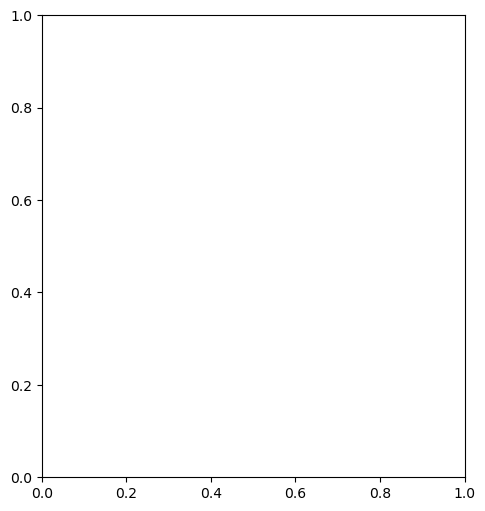

In [7]:
# from balif import Balif

data = np.random.normal(0, 1, (1024, 2)).astype(np.float64)
forest = IsolationForest(hyperplane_components=1)
# balif = Balif(hyperplane_components=1)


def heatmap(model):
    model.fit(data)
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
    coord = np.stack([X.flatten(), Y.flatten()]).T.astype(np.float64)
    scores = model.score(coord)
    plt.figure(figsize=(12, 6))
    plt.subplot(122)
    plt.imshow(scores.reshape(100, 100), extent=(-5, 5, 5, -5), cmap="YlOrRd")
    plt.colorbar()
    plt.subplot(121)
    plt.scatter(data[:, 0], data[:, 1], marker="o", c="grey", s=10)
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.grid()
    plt.show()


heatmap(forest)
# heatmap(balif)

# Time

In [ ]:
data_dim = 2
data = np.random.normal(0, 1, (10000, data_dim)).astype(np.float64)

In [ ]:
# forest.fit(data)
# balif = balif.fit(data, key=rng_fit)
# scores = forest.score(data)
# scores = balif.score(data, key=rng_score)

# print("\nIForest (numba)")
# print("fit time:")
# %timeit forest.fit(data)
# print("score time:")
# %timeit forest.score(data)

In [ ]:
# print("\nBalif (jax)")
# print("fit time:")
# %timeit balif.fit(data, key=rng_fit).beliefs.alpha.block_until_ready()
# print("score time:")
# %timeit balif.score(data, key=rng_score).block_until_ready()
# print("update time:")
# %timeit balif.register(data[0], key=rng_score, is_anomaly=False).beliefs.alpha.block_until_ready()
# print("interest time:")
# %timeit balif.interest(data, key=rng_score).block_until_ready()

In [ ]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators=128)
model.fit(data)
print("\nIForest (sklearn)")
print("fit time:")
%timeit model.fit(data)
print("score time:")
%timeit model.score_samples(data)


IForest (sklearn)
fit time:
98 ms ± 214 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
score time:
39.6 ms ± 46.3 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
